In [773]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('fivethirtyeight')
import datetime

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor     #RF
from sklearn.ensemble import AdaBoostRegressor         #AdaB

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 0. Load Data

In [774]:
train = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/train.csv')
test =  pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/test.csv')
submission = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/' + 'sampleSubmission.csv')

특성	|설명 |	Type
:-------:|:------:|:-----:
datetime|날자+시간|object
season|	계절(1:봄 ,2:여름,3:가을,4:겨울)|수치형
holiday|휴일 여부|수치형
weather|날씨 (1:맑음,2:흐림,3:비&눈,4:강한 비&눈)|수치형
temp|온도|수치형
atemp|체감온도|수치형
humidity|습도|수치형
windspeed|바람속도|수치형
casual|미등록 유저 대여 수|수치형
registered|등록 유저 대여 수|수치형
count|총 대여 수|수치형

# 1.EDA

In [775]:
df =pd.concat([train,test],ignore_index=True)

## 1.1 Summary

In [776]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0.0,1.0,1.0


In [777]:
print(df.shape)
df.info()

(17379, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    17379 non-null  object 
 1   season      17379 non-null  int64  
 2   holiday     17379 non-null  int64  
 3   workingday  17379 non-null  int64  
 4   weather     17379 non-null  int64  
 5   temp        17379 non-null  float64
 6   atemp       17379 non-null  float64
 7   humidity    17379 non-null  int64  
 8   windspeed   17379 non-null  float64
 9   casual      10886 non-null  float64
 10  registered  10886 non-null  float64
 11  count       10886 non-null  float64
dtypes: float64(6), int64(5), object(1)
memory usage: 1.6+ MB


In [778]:
df.isnull().sum()

datetime         0
season           0
holiday          0
workingday       0
weather          0
temp             0
atemp            0
humidity         0
windspeed        0
casual        6493
registered    6493
count         6493
dtype: int64

- datetime 형변환 필요
- casual , registered ,count 약 7천개 결측치 존재

## 1.2 Data Statistic

In [779]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,10886.000000,10886.000000,10886.000000
mean,2.501640,0.028770,0.682721,1.425283,20.376474,23.788755,62.722884,12.736540,36.021955,155.552177,191.574132
std,1.106918,0.167165,0.465431,0.639357,7.894801,8.592511,19.292983,8.196795,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,48.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,63.000000,12.998000,17.000000,118.000000,145.000000
75%,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,78.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


In [780]:
df.corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,-0.009585,0.013743,-0.014524,0.312025,0.319380,0.150625,-0.149773,0.096758,0.164011,0.163439
holiday,-0.009585,1.000000,-0.252471,-0.017036,-0.027340,-0.030973,-0.010588,0.003988,0.043799,-0.020956,-0.005393
workingday,0.013743,-0.252471,1.000000,0.044672,0.055390,0.054667,0.015688,-0.011830,-0.319111,0.119460,0.011594
weather,-0.014524,-0.017036,0.044672,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.135918,-0.109340,-0.128655
temp,0.312025,-0.027340,0.055390,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.467097,0.318571,0.394454
atemp,0.319380,-0.030973,0.054667,-0.105563,0.987672,1.000000,-0.051918,-0.062336,0.462067,0.314635,0.389784
humidity,0.150625,-0.010588,0.015688,0.418130,-0.069881,-0.051918,1.000000,-0.290105,-0.348187,-0.265458,-0.317371
windspeed,-0.149773,0.003988,-0.011830,0.026226,-0.023125,-0.062336,-0.290105,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


- 자전거 수요 예측에 체감온도와 습도가 중요한 feature로 예상된다.

## 1.3Data Visualization

In [781]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

#### 1.3.0 Count

<AxesSubplot:xlabel='count', ylabel='count'>

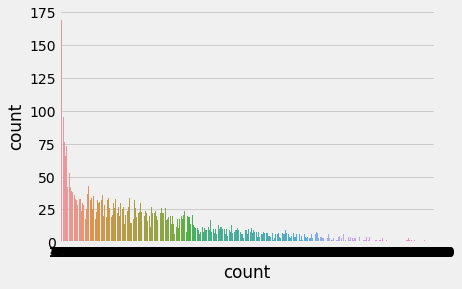

In [782]:
sns.countplot(data = df ,x ='count')

In [783]:
pd.qcut(df['count'] , q = 4)

0        (0.999, 42.0]
1        (0.999, 42.0]
2        (0.999, 42.0]
3        (0.999, 42.0]
4        (0.999, 42.0]
             ...      
17374              NaN
17375              NaN
17376              NaN
17377              NaN
17378              NaN
Name: count, Length: 17379, dtype: category
Categories (4, interval[float64, right]): [(0.999, 42.0] < (42.0, 145.0] < (145.0, 284.0] < (284.0, 977.0]]

In [784]:
df['qcut']=pd.qcut(df['count'] , q = 4,labels=[1,2,3,4])

 1~ 42
 42~145
 145~284
 284~977

#### 1.3.1 Datetime

In [785]:
df.datetime=pd.to_datetime(df.datetime)

In [786]:
df['year'] = df.datetime.dt.year
df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['hour'] = df.datetime.dt.hour
df['weekday'] = df.datetime.dt.weekday

<AxesSubplot:xlabel='weekday', ylabel='count'>

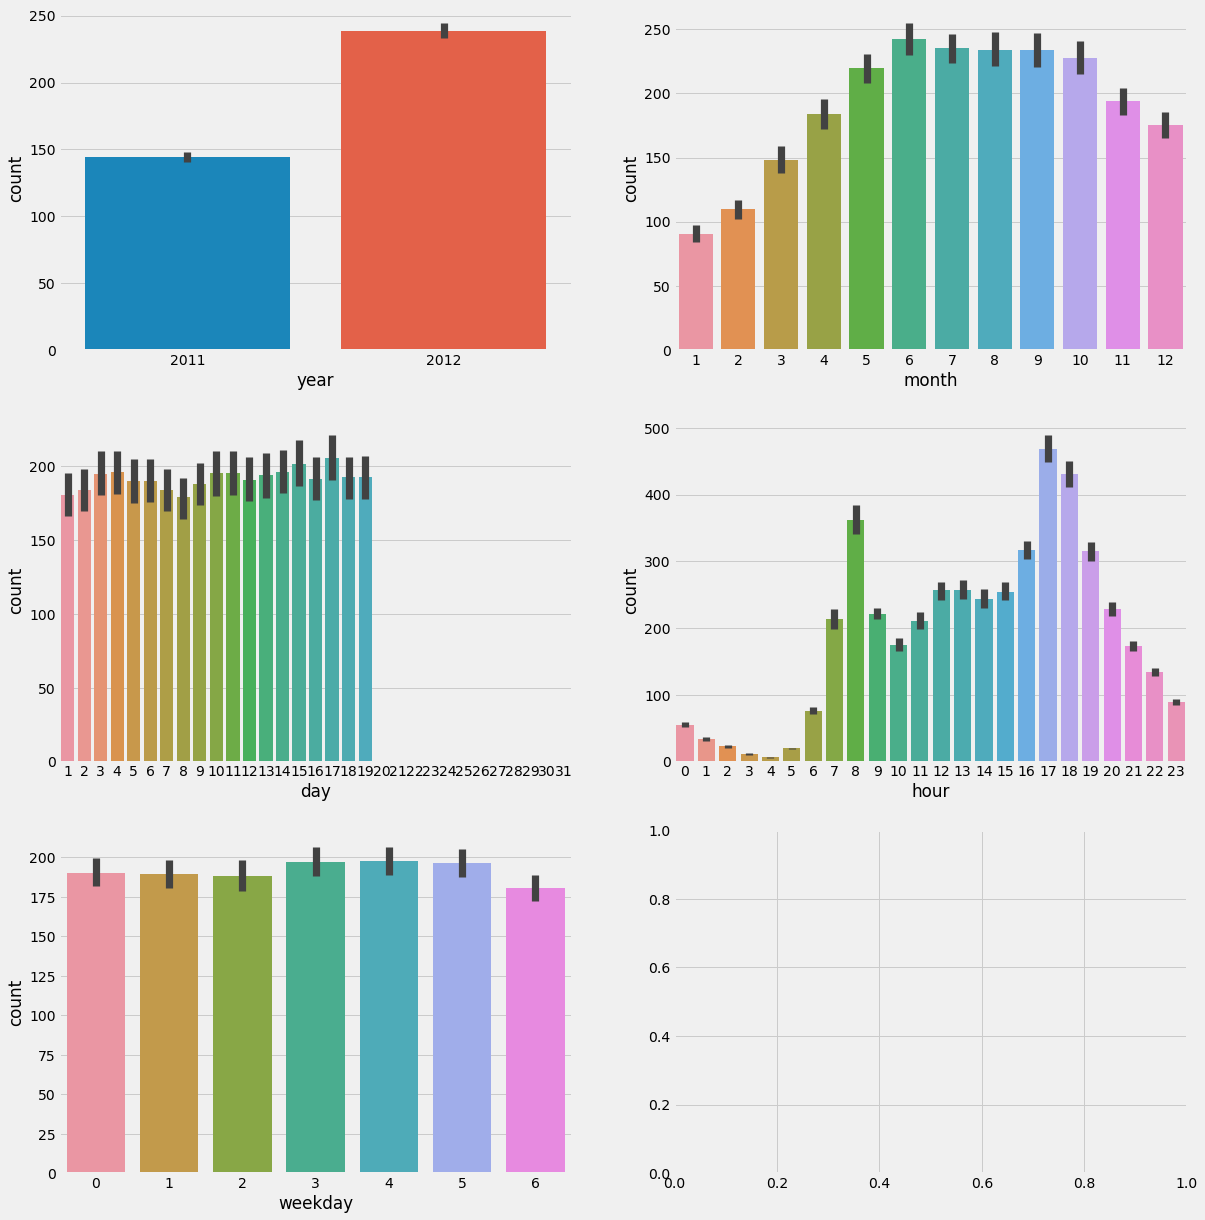

In [787]:
f ,ax = plt.subplots(3,2,figsize=(18,20))
#plt.tight_layout()  
sns.barplot(data=df ,x = 'year',y = 'count',ax=ax[0,0])
sns.barplot(data=df ,x = 'month',y = 'count',ax=ax[0,1])
sns.barplot(data=df ,x = 'day',y = 'count',ax=ax[1,0])
sns.barplot(data=df ,x = 'hour',y = 'count',ax=ax[1,1])
sns.barplot(data=df ,x = 'weekday',y = 'count',ax=ax[2,0])

In [788]:
df.day.value_counts()

1     575
5     575
17    575
9     575
13    574
21    574
20    574
19    574
15    574
14    574
16    574
8     574
7     574
4     574
12    573
23    573
2     573
3     573
24    573
10    572
25    572
6     572
22    569
11    568
26    567
18    563
28    563
27    552
29    526
30    514
31    336
Name: day, dtype: int64

1. year  2011년에 비하여 2012년이 1.5배이상 자전거 수요가 증가하였다.
2. month 겨울 겨울(1,2,3,11,12) 시즌에 비하여 여름(6,7,8,9)시즌이 자전거 수요가 많다
3. day  일자별 큰 차이는 존재하지 않지만 20일 이후 데이터는 Nan이다.
4. hour 8시와 17,18시에 큰 수요가 보인다. 이는 출퇴근과 연관되어 보인다.

- 2012년 대여수가 2011년에 약 2배가량이다.
- 월별로 본다면 겨울 보다는 여름에 대여 회수가 증가한다.
- 일별로 대여수의 차이는 유의미성을 잘 모르겠다

- 0 월요일
- 1 화요일
....
- 6 일요일

목,금,토요일 수요가 조금더 높지만 유의미하진 않아보인다.

#### 1.3.2 Season

<AxesSubplot:xlabel='season', ylabel='count'>

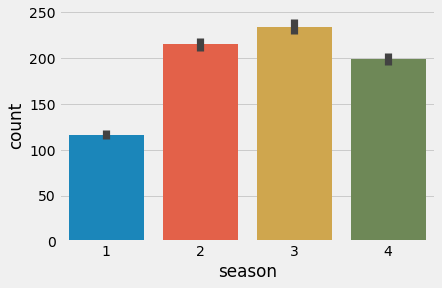

In [789]:
df.season.value_counts()
sns.barplot(data=df,x='season',y='count')

<AxesSubplot:xlabel='season', ylabel='month'>

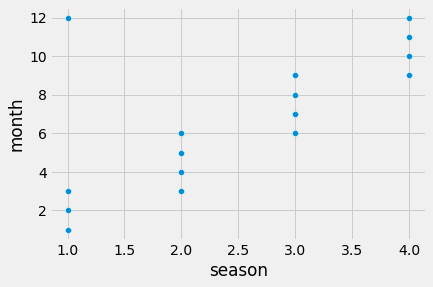

In [790]:
sns.scatterplot(data=df,x='season',y='month')

In [791]:
pd.crosstab(df.season,df.month)

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,1429,1341,949,0,0,0,0,0,0,0,0,523
2,0,0,524,1437,1488,960,0,0,0,0,0,0
3,0,0,0,0,0,480,1488,1475,1053,0,0,0
4,0,0,0,0,0,0,0,0,384,1451,1437,960


In [792]:
print(df[(df.season==1)&(df.month==12)].day.unique())
print(df[(df.season==1)&(df.month==3)].day.unique())

[21 22 23 24 25 26 27 28 29 30 31]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


season
- 시즌 1 12/21 ~3/20
- 시즌 2 3/21 ~6/20
- 시즌 3 6/21 ~9/20
- 시즌 4 9/21 ~12/20

- 1시즌은 겨울로 자전거 수요가 크게 저하된 모습이다.

#### 1.3.3 holiday

In [793]:
df.holiday.unique()

array([0, 1], dtype=int64)

<AxesSubplot:xlabel='holiday', ylabel='count'>

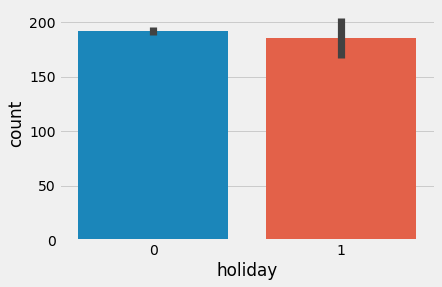

In [794]:
sns.barplot(data=df,x='holiday',y='count')

In [795]:
df[['holiday','count']].groupby('holiday').mean()

,count
holiday,
0,191.741655
1,185.877814


- 휴일유무에 따른 자전거 수요의 차이가 근소하다. 

#### 1.3.4 workingday

In [796]:
df.workingday.unique()

array([0, 1], dtype=int64)

<AxesSubplot:xlabel='workingday', ylabel='count'>

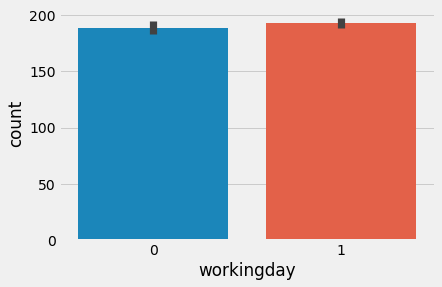

In [797]:
sns.barplot(data=df,x='workingday',y='count')

In [798]:
df[['holiday','count']].groupby('holiday').mean()

,count
holiday,
0,191.741655
1,185.877814


- wrokingday 또한 수요의 유의미한 차이가 없다

In [799]:
pd.pivot_table(df,index='holiday',columns='workingday',values='count')

workingday,0,1
holiday,,
0,188.765096,193.011873
1,185.877814,NaN


#### 1.3.5 weather

In [800]:
df.weather.unique()

array([1, 2, 3, 4], dtype=int64)

In [801]:
df.weather.value_counts()

1    11413
2     4544
3     1419
4        3
Name: weather, dtype: int64

<AxesSubplot:xlabel='weather', ylabel='count'>

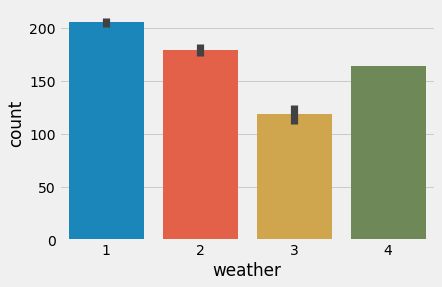

In [802]:
sns.barplot(data=df,x='weather',y='count')

- 날씨 4의경우 3개의 행밖에 없다. 따라서 drop시킨다.
- 날씨 1의 자전거 수요가 가장 높고 날씨 3의 자전거 수요가 가장 낮다. 또한 유의미한 차이가 존재한다.

#### 1.3.6 temp

In [803]:
df.temp

0         9.84
1         9.02
2         9.02
3         9.84
4         9.84
         ...  
17374    10.66
17375    10.66
17376    10.66
17377    10.66
17378    10.66
Name: temp, Length: 17379, dtype: float64

<AxesSubplot:xlabel='temp', ylabel='count'>

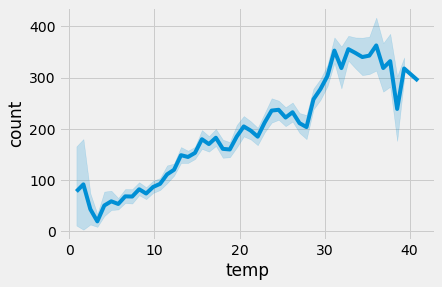

In [804]:
sns.lineplot(data=df,x='temp',y='count')

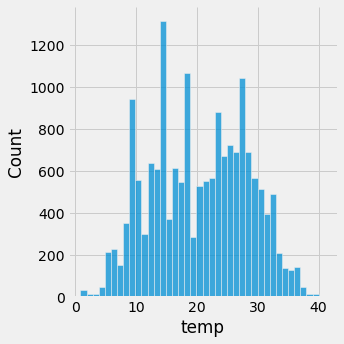

In [805]:
sns.displot(df.temp)

1. 온도에 따른 자전거 수요가 일정한 방향성을 가진다.
2. 저온에서는 자전거 수요가 낮다. 30도 까지는 증가한다. 이후 감소한다.
3. 0 ~ 10 , 10 ~ 20 ,20 ~ 30, 30~35, 35 

#### 1.3.7 atemp

In [806]:
df.atemp

0        14.395
1        13.635
2        13.635
3        14.395
4        14.395
          ...  
17374    12.880
17375    12.880
17376    12.880
17377    13.635
17378    13.635
Name: atemp, Length: 17379, dtype: float64

<AxesSubplot:xlabel='atemp', ylabel='count'>

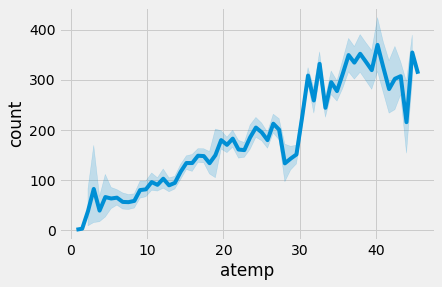

In [807]:
sns.lineplot(data=df,x='atemp',y='count')

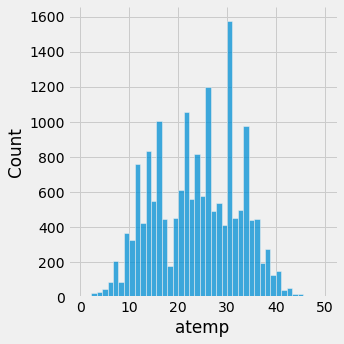

In [808]:
sns.displot(df.atemp)

1. temp와 마찬가지로 온도 상승에 따라 자전거 수요량이 증가한다.
2. 하지만 temp와 상관성이 높아보여 독립성이 보장이 안된다.

#### 1.3.8 humidity

In [809]:
df.humidity.nunique()

89

<AxesSubplot:xlabel='humidity', ylabel='count'>

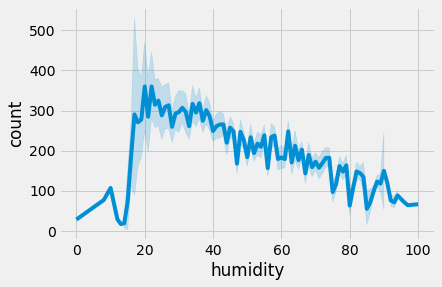

In [810]:
sns.lineplot(data=df,x='humidity',y='count')

In [811]:
df[df.humidity==17]['count'].mean()

290.5

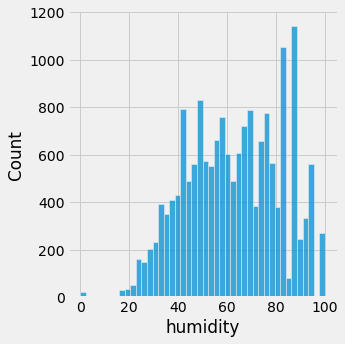

In [812]:
sns.displot(df.humidity)

In [813]:
len(df[df.humidity==0])

22

In [814]:
df.humidity.unique()
a=[ 81,  80,  75,  86,  76,  77,  72,  82,  88,  87,  94, 100,  71,
        66,  57,  46,  42,  39,  44,  47,  50,  43,  40,  35,  30,  32,
        64,  69,  55,  59,  63,  68,  74,  51,  56,  52,  49,  48,  37,
        33,  28,  38,  36,  93,  29,  53,  34,  54,  41,  45,  92,  62,
        58,  61,  60,  65,  70,  27,  25,  26,  31,  73,  21,  24,  23,
        22,  19,  15,  67,  10,   8,  12,  14,  13,  17,  16,  18,  20,
        85,   0,  83,  84,  78,  79,  89,  97,  90,  96,  91]
a.sort()

In [815]:
a

[0,
 8,
 10,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 96,
 97,
 100]

- 0에 22개의 값이 존재하지만  1~7까지 값이 없다.

In [816]:
df.loc[df.humidity==0,'count']

1091      3.0
1092      2.0
1093      1.0
1094      3.0
1095     12.0
1096     37.0
1097     44.0
1098     24.0
1099     17.0
1100     11.0
1101     34.0
1102     12.0
1103     12.0
1104     14.0
1105     21.0
1106    111.0
1107     82.0
1108     56.0
1109     38.0
1110     28.0
1111     34.0
1112     27.0
Name: count, dtype: float64

In [817]:
# fea = df[['temp','atemp','humidity']]
# sns.pairplot(fea, hue = 'season')

#### 1.3.9 windspeed

In [818]:
df.windspeed

0         0.0000
1         0.0000
2         0.0000
3         0.0000
4         0.0000
          ...   
17374    11.0014
17375    11.0014
17376    11.0014
17377     8.9981
17378     8.9981
Name: windspeed, Length: 17379, dtype: float64

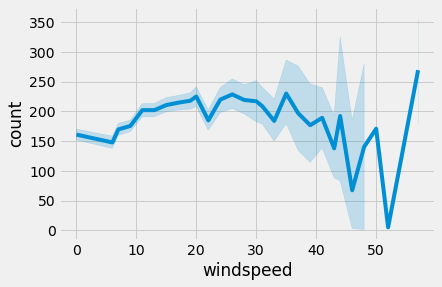

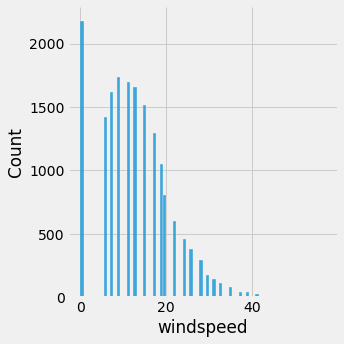

In [819]:

sns.lineplot(data=df,x='windspeed',y='count')
sns.displot(data=df,x='windspeed')

In [820]:
df.windspeed.nunique()

30

In [821]:
len(df.loc[df.windspeed==0,'count'])

2180

<AxesSubplot:>

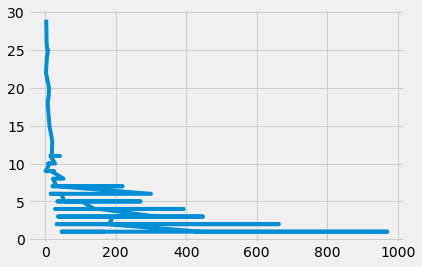

In [822]:
df.loc[df.windspeed==0,'count'].value_counts().plot(kind='line')

In [823]:
df[['windspeed','qcut']].groupby('qcut').mean()

,windspeed
qcut,
1,10.995583
2,13.012115
3,13.458363
4,13.736561


In [824]:
df.windspeed.mean()

12.736539622532943

<AxesSubplot:xlabel='windspeed', ylabel='humidity'>

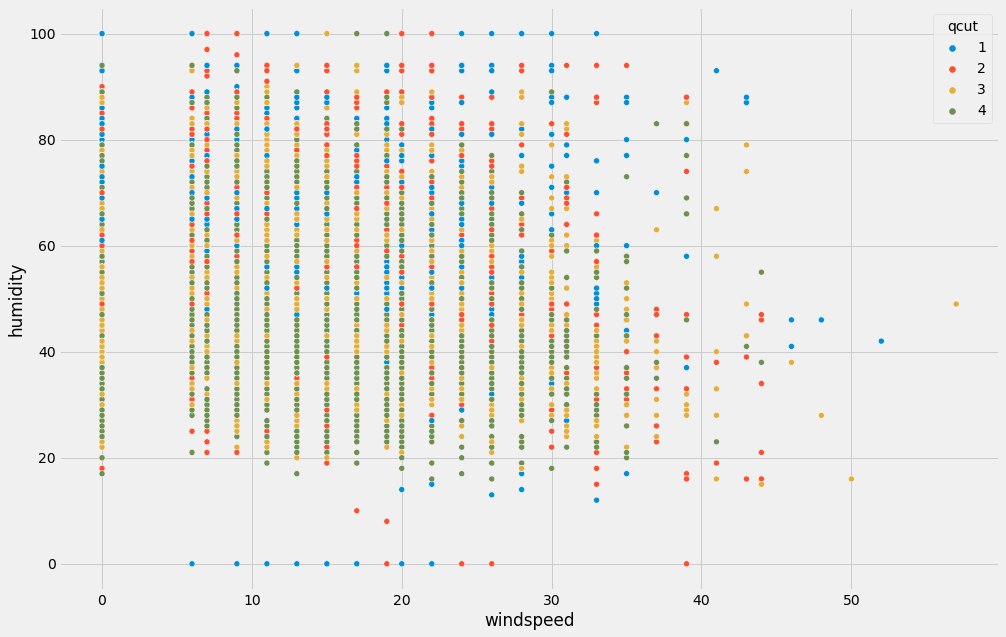

In [825]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=df,x='windspeed',y='humidity',hue='qcut')

1. 바람세기의 경우 0값이 굉장히 많다 하지만 0값이 null값을 0으로 치환한 것으로 예상된다.
2. 이를 mean또는 median으로 치환하면 좋을것같다.

#### 1.3.10 casual, registered

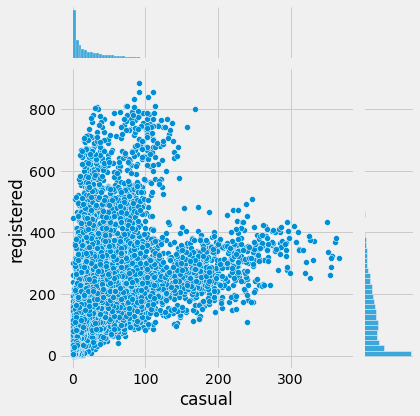

In [826]:
sns.jointplot(df.casual,df.registered)

<AxesSubplot:xlabel='casual', ylabel='registered'>

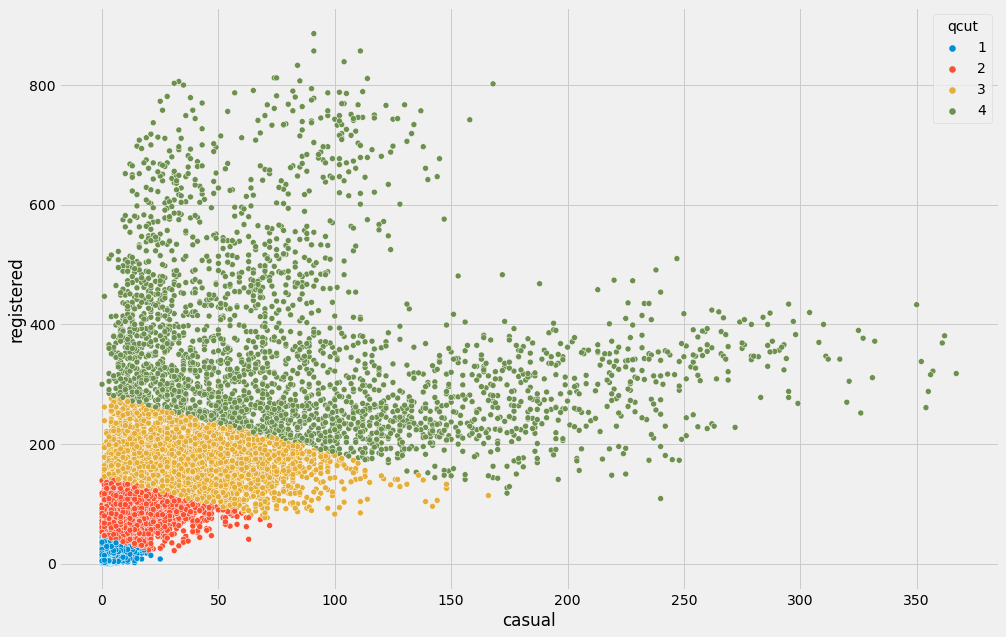

In [827]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=df,x='casual',y='registered',hue='qcut')

In [828]:
df['play'] = df.casual +df.registered

<AxesSubplot:xlabel='play', ylabel='count'>

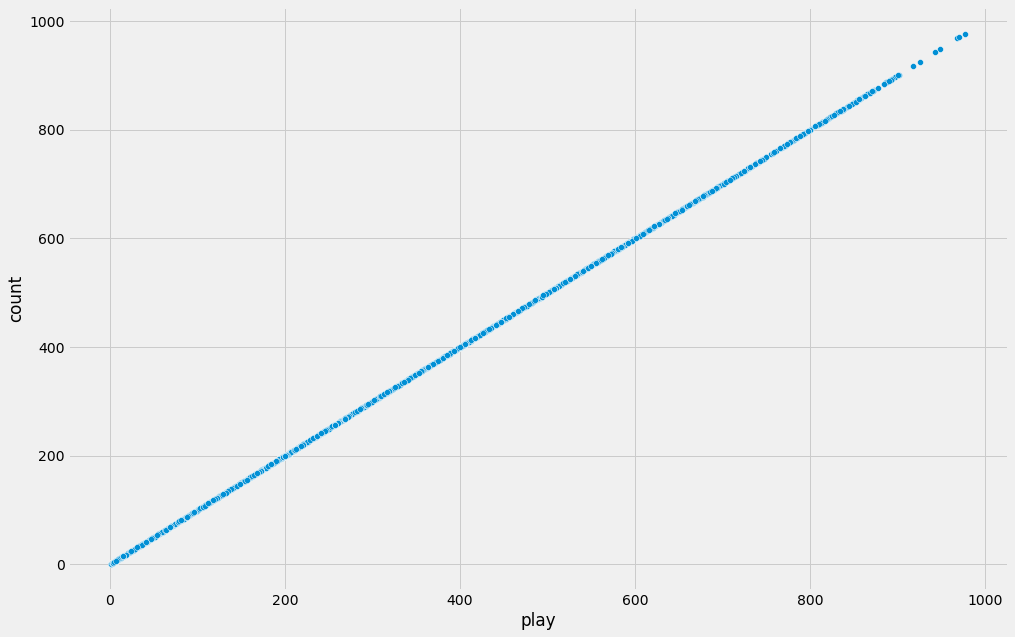

In [829]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=df,x='play',y='count')

In [830]:
test

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


# 2. Feature Engineering

1. datetime 형변환
2. 체감온도 + 습도 중요하다
3. year,month,hour 생성
4. season 1=1 2,3,4 =0치환 ->
5. holiday,workingday 유의미하지는 않다 -> 
6. weather 4 제거
7. temp atemp상관성 높기에 temp삭제 & binning
8. humidity 0 값 치환하기(평균,중앙등 통계값)
9. windspeed 0 값 치환하기
10, casual ,registerd 드랍

In [831]:
train = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/train.csv')

In [832]:
target = train['count']

In [872]:
def derived_variable(df):
    df['datetime'] = pd.to_datetime(df.datetime)
    df['year'] = df.datetime.dt.year
    df['month'] = df.datetime.dt.month
    df['hour'] = df.datetime.dt.hour
    return df

def preprocessing(df):
    #df=df[df.weather!=4]
    df.season = df.season.replace({1:True,2:False,3:False,4:False})
    return df

def replace_feature(df):
    df.humidity.replace(0,df.loc[df.humidity !=0 ,'humidity'].mean(),inplace=True)
    df.windspeed.replace(0,df.loc[df.windspeed !=0 ,'windspeed'].mean(),inplace=True)
    return df

def binning(df):
    df.atemp = pd.cut(df.atemp,bins=[0,10,20,30,40,100],labels=[1,2,3,4,5])
    df.windspeed = pd.cut(df.windspeed,bins=[0,30,40,55,1000],labels=[1,2,3,4])
    df.humidity = pd.cut(df.humidity,bins=[0,17,40,60,80,1000],labels=[1,2,3,4,5])
    return df

def drop_feature(df):
    drop_feature = ['datetime','casual','registered','count','month']
    for i in drop_feature:
        try:
            df.drop(i,axis=1,inplace=True)
        except :
            pass
    return df

def one_hot_encoding(df):
    ohe=pd.get_dummies(df.weather, prefix = 'weather')
    return pd.concat([df,ohe],ignore_index=True,axis=1)
    

def featire_engineering(df):
    df = derived_variable(df)
    df = preprocessing(df)
    df = replace_feature(df)
    #df = binning(df)
    df = drop_feature(df)
    #df = one_hot_encoding(df)
    return df


def featire_engineering_base(df):
    df = derived_variable(df)
    #df = preprocessing(df)
    #df = replace_feature(df)
    #df = binning(df)
    df = drop_feature(df)
    #df = one_hot_encoding(df)
    return df



# 3.Base Model

In [873]:
train = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/train.csv')
test =  pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/test.csv')
submission = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/' + 'sampleSubmission.csv')
target=train['count']

In [874]:
train = featire_engineering_base(train)
test = featire_engineering_base(test)

In [875]:
def rmsle(y_true, y_pred, convertExp=False):
    # 지수변환
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
        
    # 로그변환 후 결측값을 0으로 변환
    log_true = np.nan_to_num(np.log(y_true+1))
    log_pred = np.nan_to_num(np.log(y_pred+1))
    
    # RMSLE 계산
    output = np.sqrt(np.mean((log_true - log_pred)**2))
    return output

In [877]:
import numpy as np

def rmsle(y_true, y_pred, convertExp=True):
    # 지수변환
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
        
    # 로그변환 후 결측값을 0으로 변환
    log_true = np.nan_to_num(np.log(y_true+1))
    log_pred = np.nan_to_num(np.log(y_pred+1))
    
    # RMSLE 계산
    output = np.sqrt(np.mean((log_true - log_pred)**2))
    return output

In [878]:
train

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,hour
0,1,0,0,1,9.84,14.395,81,0.0000,2011,0
1,1,0,0,1,9.02,13.635,80,0.0000,2011,1
2,1,0,0,1,9.02,13.635,80,0.0000,2011,2
3,1,0,0,1,9.84,14.395,75,0.0000,2011,3
4,1,0,0,1,9.84,14.395,75,0.0000,2011,4
...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,2012,19
10882,4,0,1,1,14.76,17.425,57,15.0013,2012,20
10883,4,0,1,1,13.94,15.910,61,15.0013,2012,21
10884,4,0,1,1,13.94,17.425,61,6.0032,2012,22


In [879]:
rf  = RandomForestRegressor()
adb = AdaBoostRegressor()
xgb = XGBRegressor()
lgbm = LGBMRegressor()

In [880]:
models = [rf,xgb,lgbm]

In [881]:
target =np.log(target)

In [882]:
for model in models:
    model.fit(train,target)
    y_pred = model.predict(train)
    print(rmsle(target,y_pred,True))
    

0.12295618007771876
0.21359203568957982
0.275052157548575


In [885]:
linearreg_preds = xgb.predict(test) # 테스트 데이터로 예측

submission['count'] = linearreg_preds    # 지수변환
submission.to_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/first_submission.csv', index=False) # 파일로 저장

In [886]:
submission

,datetime,count
0,2011-01-20 00:00:00,2.568555
1,2011-01-20 01:00:00,1.204361
2,2011-01-20 02:00:00,0.814667
3,2011-01-20 03:00:00,0.514123
4,2011-01-20 04:00:00,0.289636
...,...,...
6488,2012-12-31 19:00:00,5.403868
6489,2012-12-31 20:00:00,4.908002
6490,2012-12-31 21:00:00,4.731989
6491,2012-12-31 22:00:00,4.633808


# 4. Upgrade

In [893]:
train = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/train.csv')
test =  pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/test.csv')
submission = pd.read_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/' + 'sampleSubmission.csv')
target=np.log(train['count'])



In [894]:
train=featire_engineering(train)


In [895]:
test = featire_engineering(test)


In [896]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      6493 non-null   bool   
 1   holiday     6493 non-null   int64  
 2   workingday  6493 non-null   int64  
 3   weather     6493 non-null   int64  
 4   temp        6493 non-null   float64
 5   atemp       6493 non-null   float64
 6   humidity    6493 non-null   int64  
 7   windspeed   6493 non-null   float64
 8   year        6493 non-null   int64  
 9   hour        6493 non-null   int64  
dtypes: bool(1), float64(3), int64(6)
memory usage: 463.0 KB


In [897]:
import numpy as np

def rmsle(y_true, y_pred, convertExp=True):
    # 지수변환
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
        
    # 로그변환 후 결측값을 0으로 변환
    log_true = np.nan_to_num(np.log(y_true+1))
    log_pred = np.nan_to_num(np.log(y_pred+1))
    
    # RMSLE 계산
    output = np.sqrt(np.mean((log_true - log_pred)**2))
    return output

In [898]:
for model in models:
    model.fit(train,target)
    y_pred = model.predict(train)
    print(rmsle(target,y_pred))
    

0.12828949788498945
0.2203524089734648
0.2814529708165866


In [899]:
linearreg_preds = rf.predict(test) # 테스트 데이터로 예측

submission['count'] = linearreg_preds    #
submission.to_csv('C:/Users/Lee/Desktop/GIt/AIFFEL_first/transcription_project/Bike_Sharing_Demand/first_submission1.csv', index=False) # 파일로 저장

In [900]:
test

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,hour
0,True,0,1,1,10.66,11.365,56,26.002700,2011,0
1,True,0,1,1,10.66,13.635,56,14.577694,2011,1
2,True,0,1,1,10.66,13.635,56,14.577694,2011,2
3,True,0,1,1,10.66,12.880,56,11.001400,2011,3
4,True,0,1,1,10.66,12.880,56,11.001400,2011,4
...,...,...,...,...,...,...,...,...,...,...
6488,True,0,1,2,10.66,12.880,60,11.001400,2012,19
6489,True,0,1,2,10.66,12.880,60,11.001400,2012,20
6490,True,0,1,1,10.66,12.880,60,11.001400,2012,21
6491,True,0,1,1,10.66,13.635,56,8.998100,2012,22
